In [35]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
try:
    df = pd.read_csv(r"C:\Users\ADMIN\Desktop\comp 240\iris.csv")
except FileNotFoundError:
    print("Error: File not found.")
except pd.errors.ParserError:
    print("Error: Failed to parse CSV file.")
except Exception as e:
    print(f"Unexpected error: {e}")

In [37]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [38]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [40]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [41]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

<Axes: >

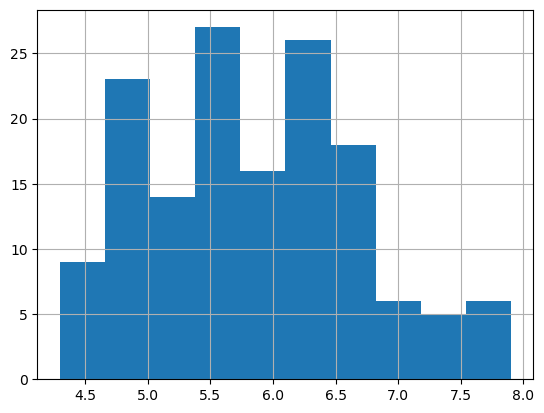

In [42]:
df['sepal_length'].hist()

<Axes: >

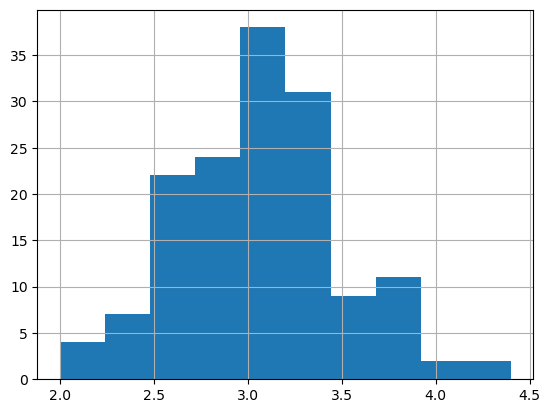

In [43]:
df['sepal_width'].hist()

<Axes: >

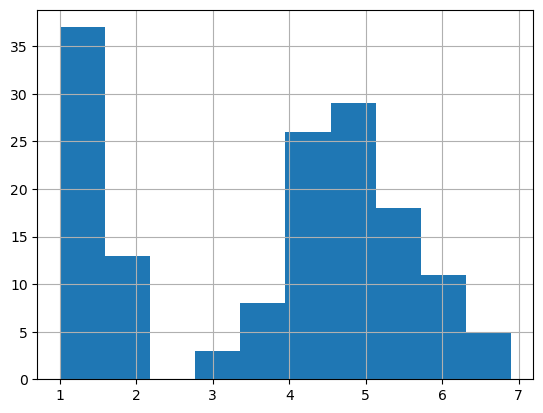

In [44]:
df['petal_length'].hist()

<Axes: >

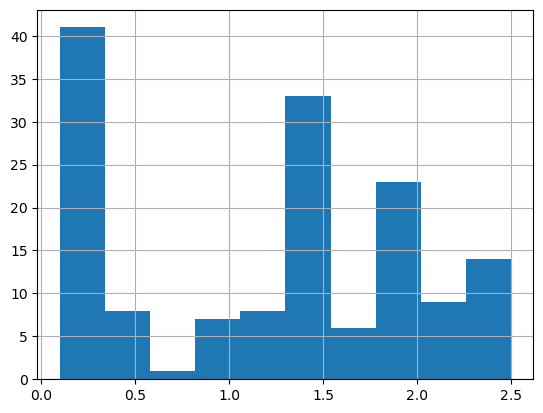

In [45]:
df['petal_width'].hist()

In [46]:
#scatter
colors = ['red' ,'grey','blue']
species = ['setosa','versicolor','virginica']

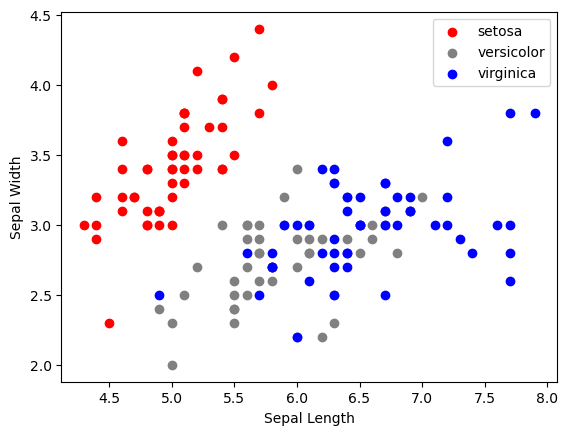

In [47]:
for i in range(3):
    x = df[df['species'] == species[i]]
    plt.scatter(x['sepal_length'],x['sepal_width'],c = colors[i],label = species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

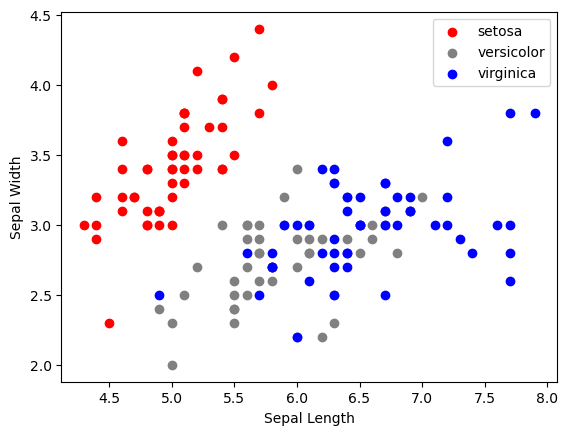

In [48]:
for i in range(3):
    x = df[df['species'] == species[i]]
    plt.scatter(x['sepal_length'],x['sepal_width'],c = colors[i],label = species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

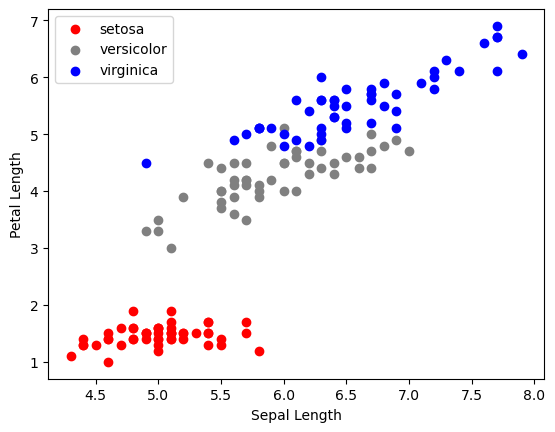

In [49]:
for i in range(3):
    x = df[df['species'] == species[i]]
    plt.scatter(x['sepal_length'],x['petal_length'],c = colors[i],label = species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()

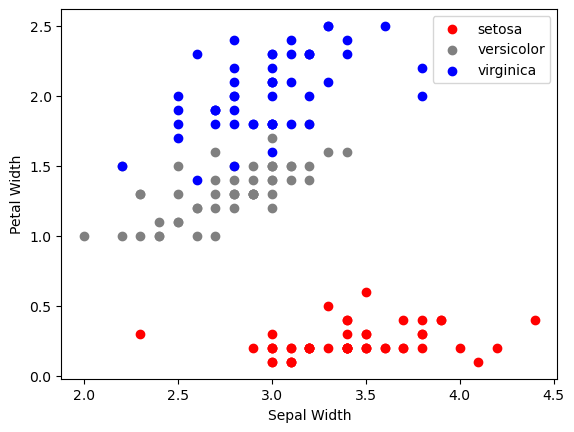

In [50]:
for i in range(3):
    x = df[df['species'] == species[i]]
    plt.scatter(x['sepal_width'],x['petal_width'],c = colors[i],label = species[i])
plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.legend()

In [51]:
corr_matrix = df.corr(numeric_only = True)

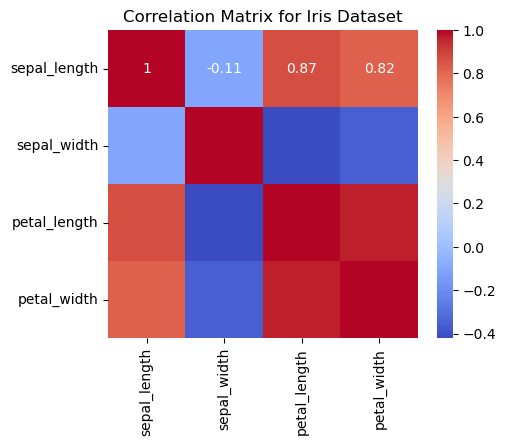

In [52]:
fig,ax = plt.subplots(figsize = (5,4))
sns.heatmap(corr_matrix,annot=True,ax=ax,cmap='coolwarm')
plt.title('Correlation Matrix for Iris Dataset')
plt.show()

In [53]:
# Importing Label Encoder
#from sklearn.preprocessing import LabelEncoder
#le = LabelEncoder()

In [54]:
# coverting species to numerical values
#df['species'] = le.fit_transform(df['species'])
#df.head()

In [55]:
# import Training model
from sklearn.model_selection import train_test_split

In [56]:
#define the variables
# 70% for training the model
# 30% fro testing the model

X = df.drop(columns = ['species'])
Y = df['species']
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size = 0.30)

In [57]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [58]:
#model training
model.fit(x_train,y_train)


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [59]:
print("Accuracy: ",model.score(x_test,y_test)*100)

Accuracy:  95.55555555555556


In [60]:
# knn - k-nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()

In [61]:
model.fit(x_train,y_train)

KNeighborsClassifier()

In [62]:
print("Accuracy: ",model.score(x_test,y_test)*100)

Accuracy:  95.55555555555556


In [63]:
# using decision tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [64]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [65]:
print("Accuracy: ",model.score(x_test,y_test)*100)

Accuracy:  97.77777777777777


In [66]:
# Saving the Model
import pickle
filename = 'savemodel.sav'
pickle.dump(model,open(filename,'wb'))

In [67]:
x_test.head()

,sepal_length,sepal_width,petal_length,petal_width
106,4.9,2.5,4.5,1.7
102,7.1,3.0,5.9,2.1
0,5.1,3.5,1.4,0.2
141,6.9,3.1,5.1,2.3
145,6.7,3.0,5.2,2.3


In [68]:
load_model = pickle.load(open(filename,'rb'))

In [69]:
load_model.predict([[6.0,3.4,4.5,1.6]])

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['versicolor'], dtype=object)